# C06 组合优化与课程收官
这一节是整个 workshop 的最后一环。

前面我们已经能做到：
- 取数据
- 构造因子
- 回测策略
- 做多因子打分

现在还差最后一个更像“投资经理”而不是“研究员”的问题：
> 当我已经知道想持有哪些资产时，权重应该怎么分？


In [ ]:
START_DATE = "2019-01-01"
END_DATE = "2024-12-31"
UNIVERSE = ["510300.XSHG", "510500.XSHG", "159915.XSHE", "512100.XSHG", "518880.XSHG", "511010.XSHG"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rqdatac

# 把教育版 license 直接粘贴到 PASSWD
PASSWD = ""

if PASSWD:
    rqdatac.init('license', PASSWD)
    print("rqdatac 初始化成功")
else:
    print("请先填写 PASSWD，再运行本单元")


rqdatac 初始化成功


## 1) 为什么组合优化值得单独讲
同样一篮子资产，权重不一样，结果可能差很多。

这一步的核心不是再找新 alpha，而是处理：
- 收益和风险怎么平衡
- 权重是否过于集中
- 能不能比简单等权更稳


In [2]:
# 用几只大类资产 ETF 做课程收官，更符合“资产配置”的直觉
assets = ["510300.XSHG", "510500.XSHG", "159915.XSHE", "513100.XSHG", "518880.XSHG"]
close = rqdatac.get_price(
    assets,
    start_date=START_DATE,
    end_date=END_DATE,
    fields=["close"],
    adjust_type="pre",
    expect_df=True,
).reset_index()

close = close.sort_values(["order_book_id", "date"]).copy()
close_wide = close.pivot(index="date", columns="order_book_id", values="close")
ret_wide = close_wide / close_wide.shift(1) - 1
ret_wide.head()


order_book_id,159915.XSHE,510300.XSHG,510500.XSHG,513100.XSHG,518880.XSHG
date,,,,,
2019-01-02,NaN,NaN,NaN,NaN,NaN
2019-01-03,-0.011885,0.000000,-0.002495,-0.003583,0.010927
2019-01-04,0.026632,0.025522,0.027285,-0.000449,-0.005230
2019-01-07,0.015900,0.004202,0.017264,0.032374,-0.004206
2019-01-08,-0.002471,0.000000,-0.002176,0.013937,-0.004576


## 2) 先看最简单的基准：等权组合
课堂里一定要先放一个基准，否则优化结果很难解释。

这里的基准就是：
- 每个月调仓一次
- 所有资产等权


In [3]:
rebalance_dates = pd.DatetimeIndex(ret_wide.resample("ME").last().index)
equal_weights = pd.DataFrame(1 / len(assets), index=rebalance_dates, columns=assets)

equal_daily = equal_weights.reindex(ret_wide.index).ffill().fillna(0)
equal_ret = (equal_daily.shift(1) * ret_wide).sum(axis=1).fillna(0)
equal_nav = (1 + equal_ret).cumprod()
equal_nav.tail()


date
2024-12-25    2.099555
2024-12-26    2.106838
2024-12-27    2.103954
2024-12-30    2.098788
2024-12-31    2.065317
dtype: float64

### 2.1 为什么先讲等权
因为等权是一个很好的教学基准：
- 没有模型门槛
- 容易理解
- 很适合和“优化后权重”做对照

如果优化结果连等权都解释不过去，那学生很难真正理解组合优化的价值。


## 3) 夏普最大化：本节主模型
上一届 `L13` 的核心是经典组合模型。
这里我们不做复杂数学推导，只保留最重要的直觉：

1. 先用过去一段时间估计预期收益和协方差
2. 再选一组权重
3. 让组合夏普比率尽量高


In [4]:
from scipy.optimize import minimize

def max_sharpe_weights(ret_window):
    mu = ret_window.mean().values
    cov = ret_window.cov().values
    n = len(mu)

    def objective(w):
        port_ret = w @ mu * 252
        port_vol = (w @ cov @ w) ** 0.5 * (252 ** 0.5)
        return -(port_ret / port_vol)

    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    bounds = [(0, 1)] * n
    w0 = np.repeat(1 / n, n)

    res = minimize(objective, w0, method="SLSQP", bounds=bounds, constraints=cons)
    return pd.Series(res.x, index=ret_window.columns)


In [5]:
# 用最近 60 个交易日做估计窗口
lookback = 60
opt_weights = []

for dt in rebalance_dates:
    hist = ret_wide.loc[:dt].dropna().tail(lookback)
    if len(hist) < lookback:
        continue
    w = max_sharpe_weights(hist)
    w.name = dt
    opt_weights.append(w)

opt_weights = pd.DataFrame(opt_weights)
opt_weights.head()


order_book_id,159915.XSHE,510300.XSHG,510500.XSHG,513100.XSHG,518880.XSHG
2019-04-30,1.246586e-01,0.000000e+00,6.004651e-17,0.732236,0.143106
2019-05-31,0.000000e+00,0.000000e+00,0.000000e+00,0.266197,0.733803
2019-06-30,7.531776e-15,0.000000e+00,3.589168e-15,0.269611,0.730389
2019-07-31,1.687159e-01,0.000000e+00,2.140519e-15,0.136012,0.695273
2019-08-31,2.630377e-01,1.122529e-15,0.000000e+00,0.261057,0.475905


### 3.1 为什么优化结果经常会“不稳定”
这是组合优化里非常值得提醒学生的一点：
- 预期收益很难估
- 协方差矩阵会变化
- 样本稍微变一下，最优权重就可能大变

所以实务里常常还会继续加：
- 约束
- 收缩
- 稳健化处理


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22799 (\N{CJK UNIFIED IDEOGRAPH-590F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: User

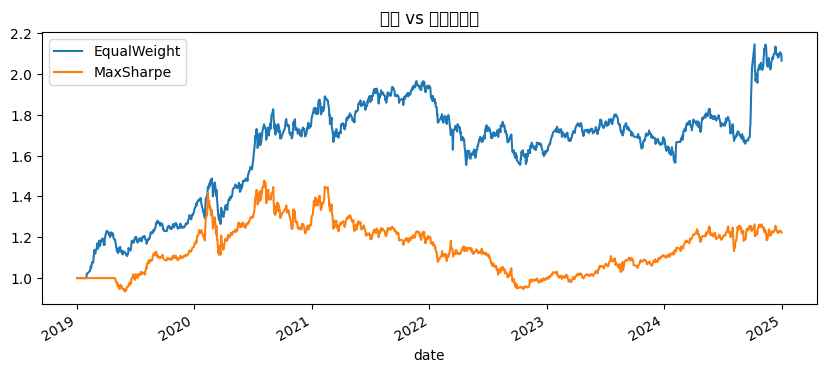

In [6]:
# 把优化权重扩展成日频，然后生成净值
opt_daily = opt_weights.reindex(ret_wide.index).ffill().fillna(0)
opt_ret = (opt_daily.shift(1) * ret_wide).sum(axis=1).fillna(0)
opt_nav = (1 + opt_ret).cumprod()

compare = pd.DataFrame({
    "EqualWeight": equal_nav,
    "MaxSharpe": opt_nav,
})

fig, ax = plt.subplots(figsize=(10, 4))
compare.plot(ax=ax)
ax.set_title("等权 vs 夏普最大化")
plt.show()


## 3.3 再补一个旧讲义里很经典的视角：有效前沿
这一节不一定要完整推导均值方差理论，但至少可以让学生看到：
- 不同权重组合会形成一片风险收益点云
- “最优组合”只是这张图上的一个点


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: User

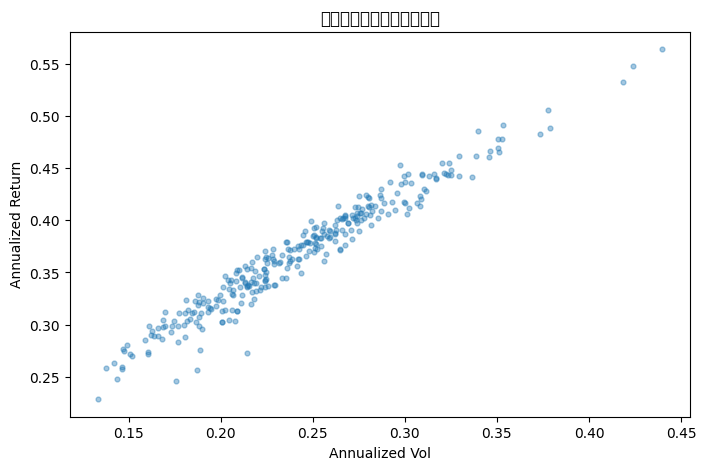

In [7]:
# 随机采样一批权重，画风险收益点云
sample_window = ret_wide.dropna().tail(120)
points = []
for _ in range(300):
    w = np.random.rand(len(assets))
    w = w / w.sum()
    port_ret = sample_window.mean().values @ w * 252
    port_vol = (w @ sample_window.cov().values @ w) ** 0.5 * (252 ** 0.5)
    points.append([port_vol, port_ret])

points = pd.DataFrame(points, columns=["vol", "ret"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(points["vol"], points["ret"], alpha=0.4, s=12)
ax.set_xlabel("Annualized Vol")
ax.set_ylabel("Annualized Return")
ax.set_title("随机权重下的风险收益分布")
plt.show()


### 3.4 夏普最大化只是一个选择，不是唯一答案
旧讲义里还会提到：
- 最小方差
- 有效前沿
- 不同风险偏好的权重选择

这节课虽然以夏普最大化为主，但最好补一句：
**组合优化不是只有一种目标函数。**


In [8]:
# 再给一个最小方差组合做对照
def min_var_weights(ret_window):
    cov = ret_window.cov().values
    n = cov.shape[0]

    def objective(w):
        return w @ cov @ w

    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    bounds = [(0, 1)] * n
    w0 = np.repeat(1 / n, n)
    res = minimize(objective, w0, method="SLSQP", bounds=bounds, constraints=cons)
    return pd.Series(res.x, index=ret_window.columns)

minvar_w = min_var_weights(sample_window)
minvar_w


order_book_id
159915.XSHE    0.2
510300.XSHG    0.2
510500.XSHG    0.2
513100.XSHG    0.2
518880.XSHG    0.2
dtype: float64

### 4.1 为什么组合优化是这套课件的收尾
因为从流程上看，这一步已经不再问：
- 哪个因子更好
- 哪个策略更强

而是在问：
- 已经选中的资产应该怎么分配资金
- 风险和收益应该怎样平衡

这也是整套课件最接近投资组合管理的一节。


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28378 (\N{CJK UNIFIED IDEOGRAPH-6EDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: User

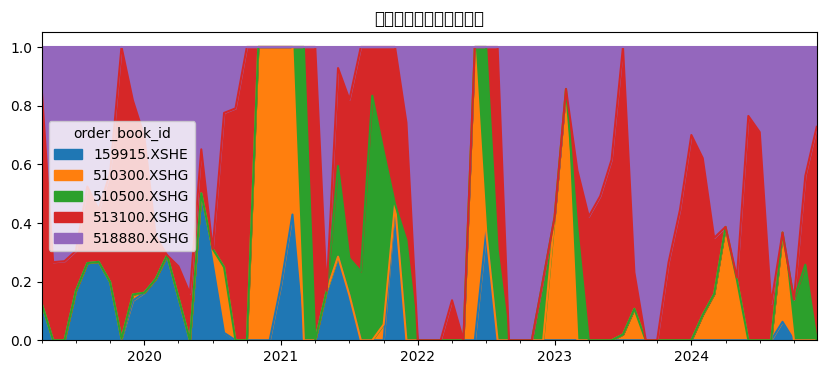

In [9]:
# 再看一次权重随时间的变化
fig, ax = plt.subplots(figsize=(10, 4))
opt_weights.plot.area(ax=ax)
ax.set_title("滚动优化得到的权重变化")
plt.show()


### 3.2 这两张图分别在看什么
1. 净值图：看“优化后”相对“等权”是否有改进
2. 权重面积图：看模型到底把钱配到了哪些资产上

很多学生只看净值图，但其实权重图同样重要，因为优化的直接输出本来就是权重。


## 4) 把前面课程串起来看
如果从整个 workshop 的角度看，这一节其实是在做：
- 前面课程负责“找信号 / 找资产”
- 这一节负责“怎么配权重”

所以它最自然地落在 `Portfolio Construction` 这个模块。


In [10]:
# 简单绩效对比
summary = pd.DataFrame({
    "cum_return": [equal_nav.iloc[-1] - 1, opt_nav.iloc[-1] - 1],
    "annual_vol": [equal_ret.std() * (252 ** 0.5), opt_ret.std() * (252 ** 0.5)],
}, index=["EqualWeight", "MaxSharpe"]).round(4)

summary


,cum_return,annual_vol
EqualWeight,1.0653,0.1594
MaxSharpe,0.2237,0.1650


## 5) 课上小练习


### 练习 1：自己看一眼最优权重
要求：
1. 取 `opt_weights` 的第一行
2. 看看哪只资产权重最高
3. 说说你觉得为什么它会被配得更重


In [11]:
# 练习 1：学生现场自己写


In [12]:
# 参考答案
first_weight = opt_weights.iloc[0].sort_values(ascending=False)
first_weight


order_book_id
513100.XSHG    7.322358e-01
518880.XSHG    1.431056e-01
159915.XSHE    1.246586e-01
510500.XSHG    6.004651e-17
510300.XSHG    0.000000e+00
Name: 2019-04-30 00:00:00, dtype: float64

### 练习 2：自己比较等权和优化
要求：
1. 把 `equal_nav` 和 `opt_nav` 放在同一张图上
2. 再输出一次 `summary`
3. 说一说：优化策略一定更好吗？


In [13]:
# 练习 2：学生现场自己写


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: User

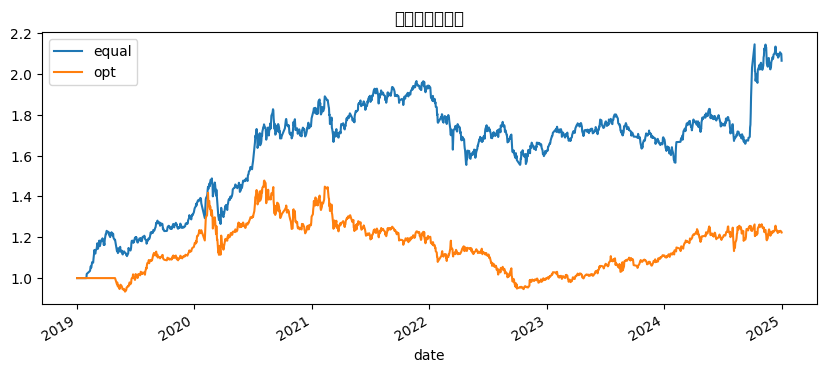

,cum_return,annual_vol
EqualWeight,1.0653,0.1594
MaxSharpe,0.2237,0.1650


In [14]:
# 参考答案
compare_ex2 = pd.DataFrame({
    "equal": equal_nav,
    "opt": opt_nav,
})
compare_ex2.plot(figsize=(10, 4), title="等权与优化对比")
plt.show()
summary


## 小结
这一节的关键词是：**组合构建**。

到这里，整个 workshop 的主线就闭环了：
1. `C01`：拿到干净、可交易的数据
2. `C02`：从财务、衍生、宏观里构造因子原料
3. `C03`：把规则接进最小回测闭环
4. `C04`：在技术指标和多资产分散化上做策略
5. `C05`：评估因子、整合多因子
6. `C06`：把资产和信号进一步转成组合权重

本节常见易错点：
1. 以为优化一定比等权好
2. 只看净值，不看权重变化
3. 忽略估计误差导致的权重不稳定
